<a href="https://colab.research.google.com/github/souptikmaiti/building-llm/blob/main/010_GPT_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **GPT ARCHITECTURE PART 5: CODING ATTENTION AND LINEAR LAYERS IN A TRANSFORMER BLOCK**

Step 1: Shortcut connection for attention block

Step 2:  Shortcut connection for feed forward block

Step 3: Add the original input back

In [ ]:
import torch
import torch.nn as nn

In [ ]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

In [ ]:
# Refer to 008_Multi_head_Attention notebbok
class MultiHeadAttention(nn.Module):

  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"
    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
    self.dropout = nn.Dropout(dropout)
    self.register_buffer("mask",torch.triu(torch.ones(context_length, context_length),diagonal=1))

  def forward(self, x):
    b, num_tokens, d_in = x.shape
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)

    # We implicitly split the matrix by adding a `num_heads` dimension
    # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
    keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
    values = values.view(b, num_tokens, self.num_heads, self.head_dim)
    queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

    # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
    keys = keys.transpose(1,2)
    queries = queries.transpose(1,2)
    values = values.transpose(1,2)

    # Compute scaled dot-product attention (aka self-attention) with a causal mask
    # keys.transpose(2, 3) -> (b, num_heads, num_tokens, head_dim).transpose(2, 3) -> (b, num_heads, head_dim, num_tokens)
    # (b, num_heads, num_tokens, head_dim) @ (b, num_heads, head_dim, num_tokens) -> (b, num_heads, num_tokens, num_tokens)
    attn_scores = queries @ keys.transpose(2, 3) # dot product for each head

    # Original mask truncated to the number of tokens and converted to boolean
    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

    # Use the mask to fill attention scores
    attn_scores.masked_fill(mask_bool, -torch.inf)

    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    # attn_weights @ values: (b, num_heads, num_tokens, num_tokens) @ (b, num_heads, num_tokens, head_dim) -> (b, num_heads, num_tokens, head_dim)
    # (b, num_heads, num_tokens, head_dim).transpose(1,2) -> (b, num_tokens, num_heads, head_dim)
    context_vecs = (attn_weights @ values).transpose(1,2)

    # Combine heads, where self.d_out = self.num_heads * self.head_dim
    context_vecs = context_vecs.contiguous().view(b, num_tokens, self.d_out) # (b, num_tokens, d_out)
    # contiguous() guarantees before we reshape the matrix the elemnts are in same block of memeory
    context_vecs = self.out_proj(context_vecs) # optional projection

    return context_vecs


In [ ]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]), ## Expansion
        GELU(), ## Activation
        nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]) ## Contraction
    )

  def forward(self, x):
    return self.layers(x)

In [ ]:
class LayerNorm(nn.Module):

  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)
    return self.scale * norm_x + self.shift # element wise multiplication and addition

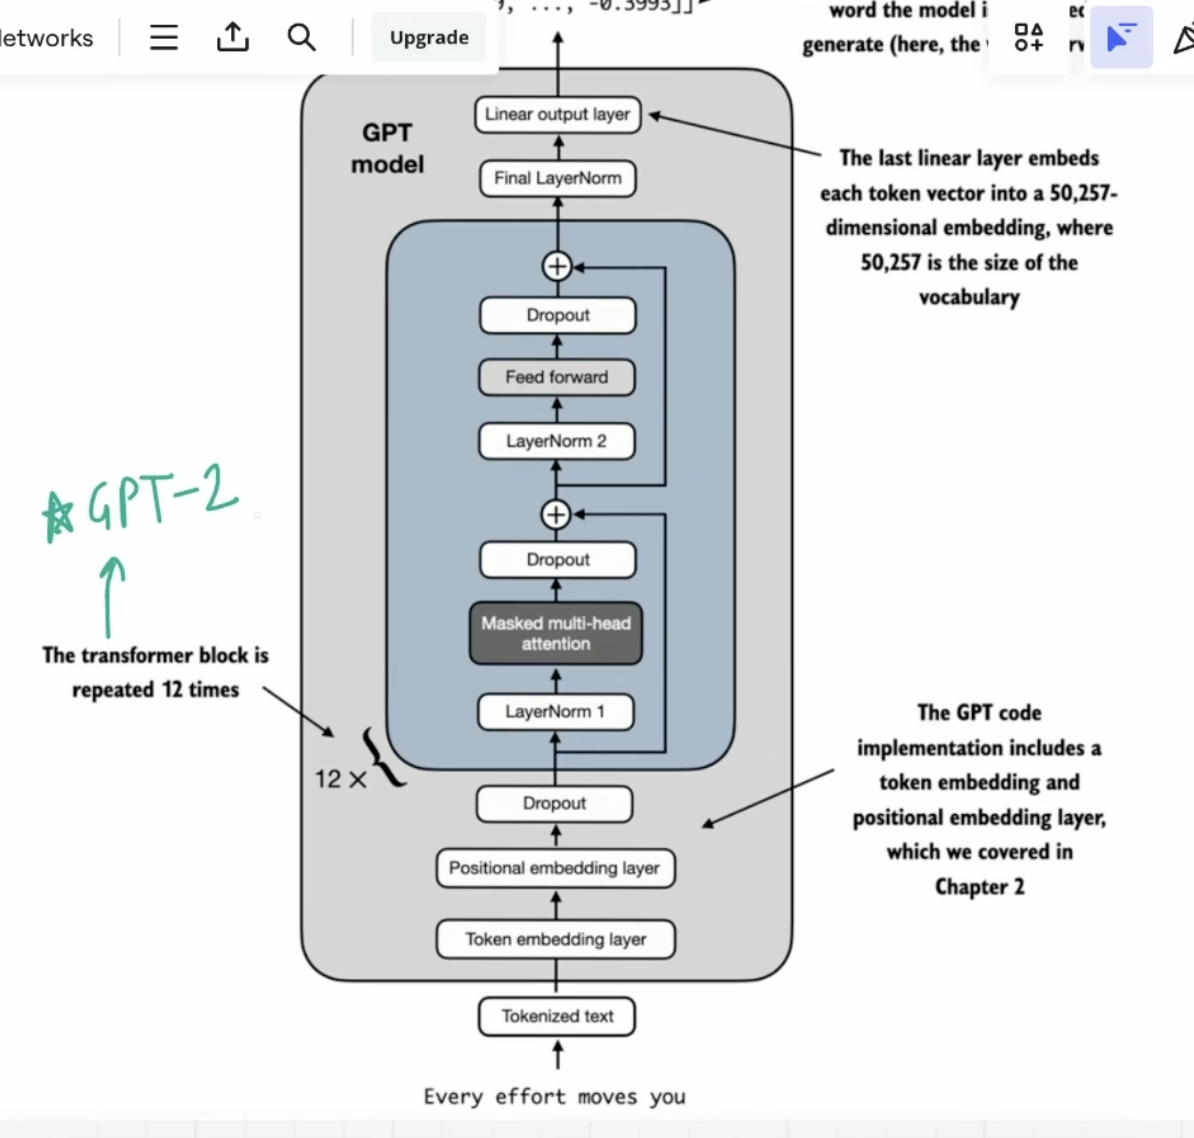

In [ ]:
class TransformerBlock(nn.Module):

  def __init__(self, cfg):
    super().__init__()

    self.att = MultiHeadAttention(
        d_in=cfg["emb_dim"],
        d_out=cfg["emb_dim"],
        context_length=cfg["context_length"],
        num_heads=cfg["n_heads"],
        dropout=cfg["drop_rate"],
        qkv_bias=cfg["qkv_bias"]
    )
    self.ff = FeedForward(cfg)
    self.norm1 = LayerNorm(cfg["emb_dim"])
    self.norm2 = LayerNorm(cfg["emb_dim"])
    self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

  def forward(self, x):
    # Shortcut / Skip connection for attention block
    shortcut = x
    x = self.norm1(x)
    x = self.att(x) # Shape [batch_size, num_tokens, emb_size]
    x = self.drop_shortcut(x)
    x = x + shortcut # Add a shortcut at this position

    # Shortcut / Skip connection for feed forward block
    shortcut = x
    x = self.norm2(x)
    x = self.ff(x)
    x = self.drop_shortcut(x)
    x = x + shortcut # Add a shortcut at this position

    return x


The given code defines a TransformerBlock class in PyTorch that includes a multi-head
attention mechanism (MultiHeadAttention) and a feed forward network (FeedForward),
both configured based on a provided configuration dictionary (cfg), such as
GPT_CONFIG_124M

Layer normalization (LayerNorm) is applied before each of these two components, and
dropout is applied after them to regularize the model and prevent overfitting.

This is also known as Pre-LayerNorm.

Older architectures, such as the original transformer model,
applied layer normalization after the self-attention and feed-forward networks instead,
known as Post-LayerNorm, which often leads to worse training dynamics.

The class also implements the forward pass, where each component is followed by a
shortcut connection that adds the input of the block to its output. This critical feature helps
gradients flow through the network during training and improves the learning of deep
models

Using the GPT_CONFIG_124M dictionary we defined earlier, let's instantiate a transformer
block and feed it some sample data

Create sample input of shape [batch_size, num_tokens, emb_dim]


In [ ]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768) #A
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)
print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


As we can see from the code output, the transformer block maintains the input dimensions
in its output, indicating that the transformer architecture processes sequences of data
without altering their shape throughout the network.

The preservation of shape throughout the transformer block architecture is not incidental
but a crucial aspect of its design.

This design enables its effective application across a wide
range of sequence-to-sequence tasks, where each output vector directly corresponds to an
input vector, maintaining a one-to-one relationship.

However, the output is a context vector
that encapsulates information from the entire input sequence.

This means that while the physical dimensions of the sequence (length and feature size)
remain unchanged as it passes through the transformer block, the content of each output
vector is re-encoded to integrate contextual information from across the entire input
sequence.

## **GPT ARCHITECTURE PART 6: ENTIRE GPT MODEL ARCHITECTURE IMPLEMENTATION**

The device setting will allow us to train the model on a CPU or GPU, depending on which device the input
data sits

In [ ]:
class GPTModel(nn.Module):

  def __init__(self, cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])

    self.trf_blocks = nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
    )

    self.final_norm = LayerNorm(cfg["emb_dim"])

    self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

  def forward(self, in_idx):
    batch_size, seq_len = in_idx.shape
    tok_embeds = self.tok_emb(in_idx)
    pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
    x = tok_embeds + pos_embeds
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits


The __init__ constructor of this GPTModel class initializes the token and positional
embedding layers using the configurations passed in via a Python dictionary, cfg.

These
embedding layers are responsible for converting input token indices into dense vectors and
adding positional information.

Next, the __init__ method creates a sequential stack of TransformerBlock modules
equal to the number of layers specified in cfg.

Following the transformer blocks, a
LayerNorm layer is applied, standardizing the outputs from the transformer blocks to
stabilize the learning process.

Finally, a linear output head without bias is defined, which
projects the transformer's output into the vocabulary space of the tokenizer to generate
logits for each token in the vocabulary.

The forward method takes a batch of input token indices, computes their embeddings,
applies the positional embeddings, passes the sequence through the transformer blocks,
normalizes the final output, and then computes the logits, representing the next token's
unnormalized probabilities. We will convert these logits into tokens and text outputs in the
next section.

Let's now initialize the 124 million parameter GPT model using the GPT_CONFIG_124M
dictionary we pass into the cfg parameter and feed it with the batch text input we created
at the beginning of this chapter:

In [ ]:
import tiktoken
tokenizer = tiktoken.get_encoding('gpt2')

batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))

batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [ ]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.4621, -0.0154, -0.1593,  ...,  0.3658,  0.0920, -0.2225],
         [ 0.3052, -0.6928, -0.8333,  ..., -0.2931,  0.3620, -0.2400],
         [ 1.0947,  0.0717, -0.2853,  ...,  0.0149, -0.5473, -0.0406],
         [-0.8236,  0.5507, -0.2304,  ...,  0.7334,  0.3817,  0.0716]],

        [[-0.5637, -0.2345, -0.1076,  ...,  0.3001,  0.1730, -0.4058],
         [ 0.2434,  0.3789, -0.1103,  ...,  0.7320,  0.0596,  0.4420],
         [ 1.0684,  0.7775, -0.1391,  ...,  0.7144,  0.1065, -0.2094],
         [-0.0695,  0.5704,  0.1656,  ...,  1.2491, -0.2159,  0.0588]]],
       grad_fn=<UnsafeViewBackward0>)


As we can see, the output tensor has the shape [2, 4, 50257], since we passed in 2 input
texts with 4 tokens each. The last dimension, 50,257, corresponds to the vocabulary size of
the tokenizer. In the next section, we will see how to convert each of these 50,257-
dimensional output vectors back into tokens.

Using the numel() method, short for "number of elements," we can collect the total
number of parameters in the model's parameter tensors:

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


Earlier, we spoke of initializing a 124
million parameter GPT model, so why is the actual number of parameters 163 million, as
shown in the preceding code output?

The reason is a concept called weight tying that is used in the original GPT-2
architecture, which means that the original GPT-2 architecture is reusing the weights from
the token embedding layer in its output layer.

To understand what this means, let's take a
look at the shapes of the token embedding layer and linear output layer that we initialized
on the model via the GPTModel earlier:

In [ ]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Token embedding layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Token embedding layer shape: torch.Size([50257, 768])


As we can see based on the print outputs, the weight tensors for both these layers have the
same shape:

The token embedding and output layers are very large due to the number of rows for the
50,257 in the tokenizer's vocabulary. Let's remove the output layer parameter count from
the total GPT-2 model count according to the weight tying:

In [ ]:
total_params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 124,412,160


As we can see, the model is now only 124 million parameters large, matching the original
size of the GPT-2 model.

Weight tying reduces the overall memory footprint and computational complexity of the
model. However, in my experience, using separate token embedding and output layers
results in better training and model performance; hence, we are using separate layers in
our GPTModel implementation. The same is true for modern LLMs.

Lastly, let us compute the memory requirements of the 163 million parameters in our
GPTModel object:

In [ ]:
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


In conclusion, by calculating the memory requirements for the 163 million parameters in
our GPTModel object and assuming each parameter is a 32-bit float taking up 4 bytes, we
find that the total size of the model amounts to 621.83 MB, illustrating the relatively large
storage capacity required to accommodate even relatively small LLMs.

## **GPT ARCHITECTURE PART 7: GENERATING TEXT FROM OUTPUT TOKENS**

Let us implement the token-generation process as follows:

Step 1: idx is a (batch, n_tokens) array of indices in the current context

Step 2: Crop current context if it exceeds the supported context size E.g., if LLM supports only 5 tokens, and the
context size is 10 then only the last 5 tokens are used as context

Step 3: Focus only on the last time step, so that (batch, n_token, vocab_size) becomes (batch, vocab_size)

Step 4: probas has shape (batch, vocab_size)

Step 5: idx_next has shape (batch, 1)

Step 6: Append sampled index to the running sequence, where idx has shape (batch, n_tokens+1)

In [ ]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
  # idx is (batch, n_tokens) array of indices in the current context, like:
  # idx = tensor([[6109, 3626, 6100,  345],
  #               [6109, 1110, 6622,  257]])

  for _ in range(max_new_tokens):

    # Crop current context if it exceeds the supported context size
    # E.g., if LLM supports only 5 tokens, and the context size is 10
    # then only the last 5 tokens are used as context
    idx_cond = idx[:, -context_size:]

    # Get the prdictions
    with torch.no_grad():
      logits = model(idx_cond)

    # Focus only on the last time step/ last token
    # (batch, n_tokens, vocab_size) -> (batch, vocab_size)
    logits = logits[:, -1, :]

    # Apply softmax to get probabilities
    probas = torch.softmax(logits, dim=-1) # (batch, vocab_size)

    # Get the index/token id of most probable token
    next_idx = torch.argmax(probas, dim=-1, keepdim=True) # (batch, 1)

    # Append sampled index to the running sequence
    idx = torch.cat((idx, next_idx), dim=-1) # (batch, n_tokens + 1)

  return idx


In the preceeding code, the generate_text_simple function, we use a softmax function to
convert the logits into a probability distribution from which we identify the position with the
highest value via torch.argmax.

The softmax function is monotonic, meaning it preserves
the order of its inputs when transformed into outputs.

So, in practice, the softmax step is
redundant since the position with the highest score in the softmax output tensor is the
same position in the logit tensor.

In other words, we could apply the torch.argmax function
to the logits tensor directly and get identical results.

However, we coded the conversion to
illustrate the full process of transforming logits to probabilities, which can add additional
intuition, such as that the model generates the most likely next token, which is known as
greedy decoding.

In the next chapter, when we will implement the GPT training code, we will also
introduce additional sampling techniques where we modify the softmax outputs such that
the model doesn't always select the most likely token, which introduces variability and
creativity in the generated text.

Let's now try out the generate_text_simple function with the "Hello, I am" context
as model input

First, we encode the input context into token IDs:

In [ ]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0) #A without unsqueeze(0) - torch.Size([4])

print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


Next, we put the model into .eval() mode, which disables random components like
dropout, which are only used during training, and use the generate_text_simple function
on the encoded input tensor:

We disable dropout since we are not training the model


In [ ]:
model.eval() # bypasses some layers like normalization layers, dropout layers
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 29739,   554]])
Output length: 10


Using the .decode method of the tokenizer, we can convert the IDs back into text:


In [ ]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswick Exit In


As we can see, based on the preceding output, the model generated gibberish, which is not
at all coherent text.

What happened?

The reason why the model is unable to produce coherent text is that we haven't trained it yet.

So far, we just
implemented the GPT architecture and initialized a GPT model instance with initial random
weights.